# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset.
 The dataset contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
property_df = pd.read_csv('ames.csv')
property_df.head(10)

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900
5,1998,1998,926,926,678,1604,2,1,3,1,7,1,470,195500
6,2001,2001,1338,1338,0,1338,2,0,2,1,6,0,582,213500
7,1992,1992,1280,1280,0,1280,2,0,2,1,5,0,506,191500
8,1995,1996,1595,1616,0,1616,2,0,2,1,5,1,608,236500
9,1999,1999,994,1028,776,1804,2,1,3,1,7,1,442,189000


In [21]:
property_df['Story'] = property_df['Story'].replace({'Double Story': 1, 'Single Story': 0})
property_df.rename(columns={'Story':'Is_Double_Story'}, inplace=True)
property_df[['First_Flr_SF','Second_Flr_SF','Is_Double_Story']]

,First_Flr_SF,Second_Flr_SF,Is_Double_Story
0,1656,0,0
1,896,0,0
2,1329,0,0
3,2110,0,0
4,928,701,1
...,...,...,...
2925,1003,0,0
2926,902,0,0
2927,970,0,0
2928,1389,0,0


### Average price vs sales volume (story type)
**Average Sale Price**  
Single story: 175,000  
Double story: 180,000  
Double-story houses achieve a small premium (~3%).  
This premium is modest, suggesting buyers are not paying much extra just for having two floors.  
  
**Sales Volume**  
Single story: 1,650 houses  
Double story: 1,250 houses  
Single-story homes are more flexible and appeal to a broader market (families, elderly buyers, accessibility, lower maintenance).  
Despite slightly lower prices, they sell more frequently, indicating stronger demand.

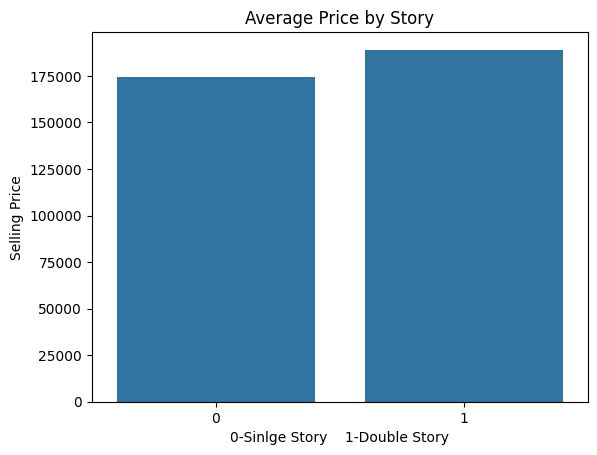

In [35]:
avg_price_by_story = property_df.groupby('Is_Double_Story')[['Sale_Price']].mean()

sns.barplot(x='Is_Double_Story', y='Sale_Price', data=avg_price_by_story)
plt.title('Average Price by Story')
plt.ylabel('Selling Price')
plt.xlabel('0-Sinlge Story    1-Double Story')
plt.show()

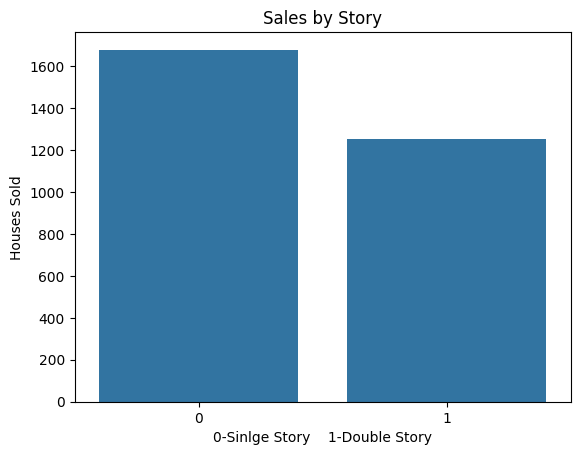

In [36]:
sales_by_story = property_df.groupby('Is_Double_Story')[['Sale_Price']].count()

sns.barplot(x='Is_Double_Story', y='Sale_Price', data=sales_by_story)
plt.title('Sales by Story')
plt.ylabel('Houses Sold')
plt.xlabel('0-Sinlge Story    1-Double Story')
plt.show()

### Price & sales by number of rooms
**Price trends**    
Prices generally increase with number of rooms for both story types.  
Single-story prices peak sharply around 10–11 rooms, suggesting large single-story homes are rare and highly valued.  
Double-story homes maintain more consistent pricing across higher room counts (10–14 rooms).  
For larger homes, buyers may prefer spreading space vertically (double-story) rather than horizontally.  
Exceptionally large single-story homes command a scarcity premium.  
  
**Sales trends**  
Single-story sales peak at 5–6 rooms - average family-sized homes.  
Double-story sales peak at 6–8 rooms, then taper off gradually.  
Very large homes (10+ rooms) sell far less frequently, regardless of story type.  
The market sweet spot is:  
Single-story: 4–6 rooms  
Double-story: 6–8 rooms  
Beyond that, demand drops faster than price rises.

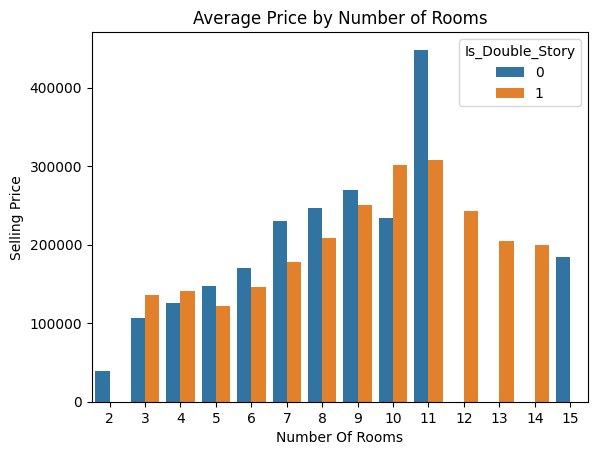

In [58]:
avg_price_by_rooms = property_df.groupby(['TotRms_AbvGrd', 'Is_Double_Story'])[['Sale_Price']].mean().reset_index()
sns.barplot(x='TotRms_AbvGrd', y='Sale_Price', hue='Is_Double_Story', data=avg_price_by_rooms)
plt.title('Average Price by Number of Rooms')
plt.ylabel('Selling Price')
plt.xlabel('Number Of Rooms')
plt.show()

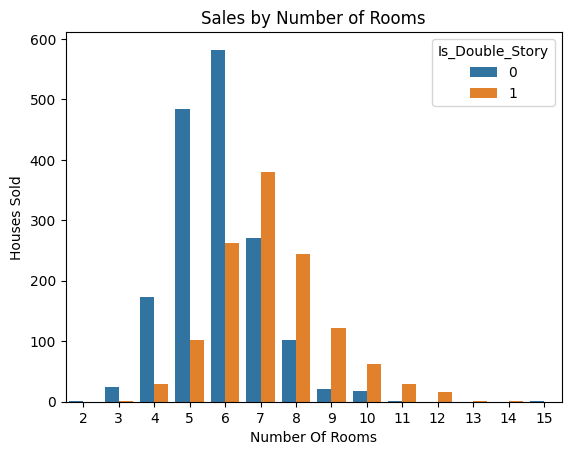

In [59]:
sales_by_rooms = property_df.groupby(['TotRms_AbvGrd', 'Is_Double_Story'])[['Sale_Price']].count()
sns.barplot(x='TotRms_AbvGrd', y='Sale_Price', hue='Is_Double_Story', data=sales_by_rooms)
plt.title('Sales by Number of Rooms')
plt.ylabel('Houses Sold')
plt.xlabel('Number Of Rooms')
plt.show()

In [68]:
SF_Diff = property_df['First_Flr_SF'] - property_df['Total_Bsmt_SF']
property_df['Total_SF'] = np.where(SF_Diff >= 0, property_df['First_Flr_SF'], property_df['First_Flr_SF'] + SF_Diff.abs())
property_df[property_df['Total_Bsmt_SF'] > property_df['First_Flr_SF']][['Total_Bsmt_SF','First_Flr_SF','Total_SF']]

,Total_Bsmt_SF,First_Flr_SF,Total_SF
28,1405,1337,1405
46,2846,2696,2846
104,1642,1418,1642
145,1268,1264,1268
200,1124,1068,1124
...,...,...,...
2657,1020,908,1020
2725,1865,1830,1865
2738,1776,1560,1776
2764,1624,1582,1624


### Correlation analysis
**Strongest drivers**  
Garage Area  
Total Square Footage  
This suggestes that functional space is more important than layout.  
Buyers value parking/storage and usable living area more than vertical complexity.  

**Moderate drivers**  
Total Rooms  
Room count matters, but less than how large those rooms are.  
This aligns with real-world pricing: fewer large rooms can outperform many small ones.  
  
**Weak drivers**  
Second Flroor Square Footage  
Story	0.09  
Simply having a second floor explains almost none of the price variation.  
Second-floor space adds value, but far less efficiently than first-floor or total area.

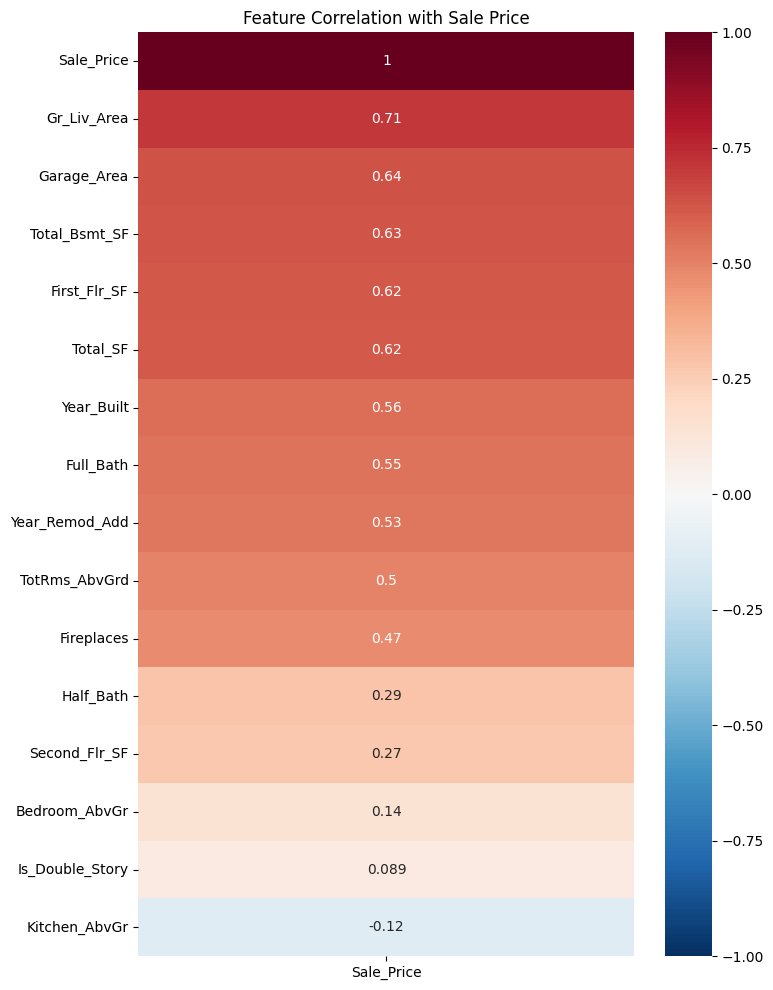

In [69]:
price_correlations = property_df.corr(numeric_only=True)[['Sale_Price']].sort_values(by='Sale_Price', ascending=False)

plt.figure(figsize=(8, 12))
# annot=True: Shows the correlation numbers
# cmap='RdBu_r': Red for positive, Blue for negative
# vmin=-1, vmax=1: Standardizes the color scale
heatmap = sns.heatmap(price_correlations, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)

plt.title('Feature Correlation with Sale Price')
plt.show()

#### Combined effect: rooms + story type

Combined correlation with Sale_Price: 0.19  
Room count and story type together explain very little of sale price on their own.  
This strongly suggests multicollinearity with size variables (rooms and stories are proxies for area).

In [70]:
property_df['Rooms_x_Story'] = property_df['TotRms_AbvGrd'] * property_df['Is_Double_Story']
combined_corr = property_df[['Rooms_x_Story', 'Sale_Price']].corr().iloc[0, 1]
combined_corr

np.float64(0.18795688834932037)

### Distributions  of  the  Dependent  Variable  and  Independent Variables
**Sale_Price (dependent variable)**  
The market is not symmetric - skewed to the right, Mean > Median.  
A small number of high-priced homes (luxury properties) exist.  
The average sale price is inflated by a few expensive properties and may not represent a "typical" home.  
  
**Garage_Area** 
The Garage Area is also skewed to the right.  
Most homes have standard-sized garages.  
A few homes have very large garages.  
Extra garage space is rare but strongly associated with higher prices.  
  
**Living Area**
The living Area is skewed to the right.  
Most houses fall within a normal family-home size range  
A small subset of houses are significantly larger  
Buyers pay a premium for size, but very large homes are uncommon.

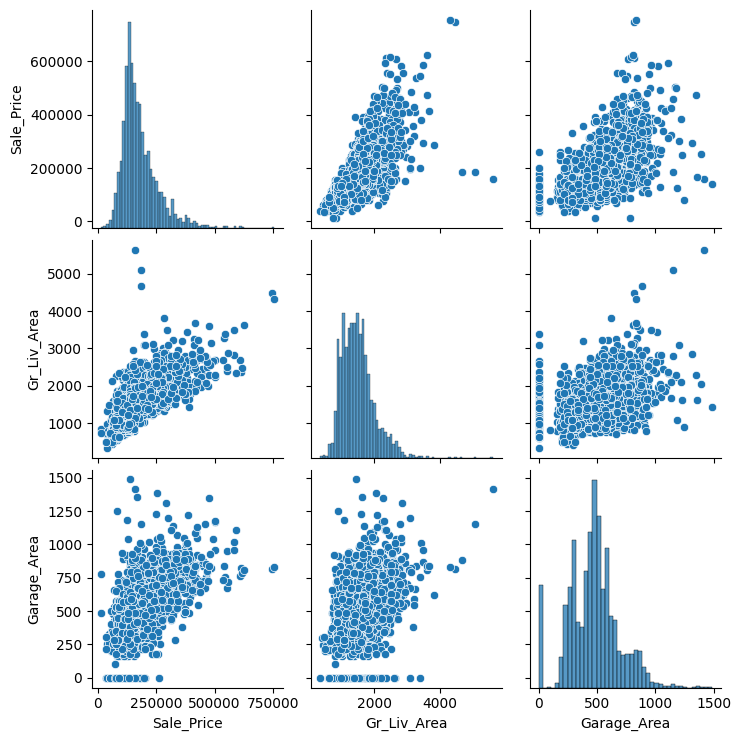

In [83]:
sns.pairplot(data=property_df[['Sale_Price','Gr_Liv_Area','Garage_Area']])
plt.show()

In [105]:
# Split the independent variables from the dependent variable
# The data doesn't follow a Gausian distribution, the log is used to attempt to fix the skewness
X = np.log(property_df[['Gr_Liv_Area', 'Garage_Area']] + [0, 1])
y = np.log(property_df['Sale_Price'])

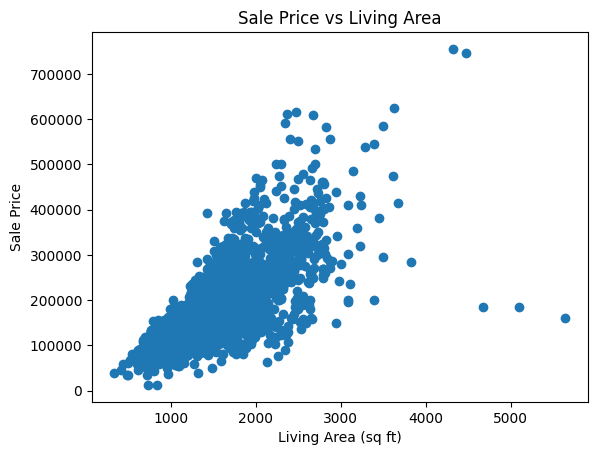

In [101]:
# Generate plots to explore the relationships between the independent and dependent variables
plt.scatter(property_df['Gr_Liv_Area'], property_df['Sale_Price'])
plt.title('Sale Price vs Living Area')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

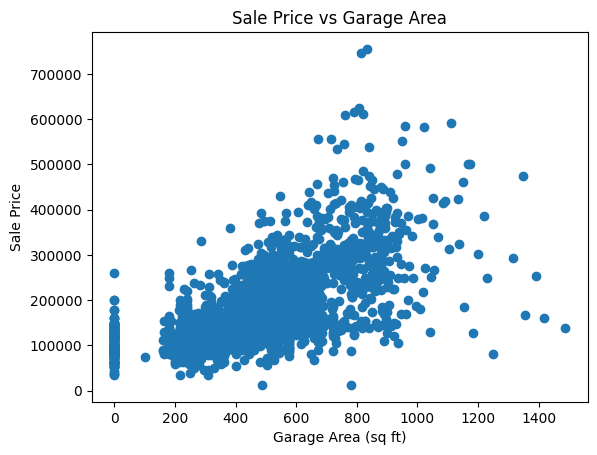

In [102]:
plt.scatter(property_df['Garage_Area'], property_df['Sale_Price'])
plt.title('Sale Price vs Garage Area')
plt.xlabel('Garage Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

In [107]:
# Create a training and test set with a 75:25 split ratio
# The random_state ensures that the data is shuffled and split the exact same way every time the code is run 
rseed = 23
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 
0.25, shuffle=True, random_state=rseed)

In [109]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
# Fit a model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

In [110]:
# Print the trained model's intercept and coefficients
print('Intercept: \n', model.intercept_)
print('Coefficients: \n', model.coef_)

Intercept: 
 5.56216606277004
Coefficients: 
 [0.83083521 0.07392493]


In [112]:
# Generate predictions for the test set
y_pred_price = np.exp(y_pred)
y_pred_price[0:10]

array([104236.91095504, 157958.83397547, 155217.7585509 ,  71676.5433486 ,
       337819.60874008, 205339.24744641, 254726.39480745, 266982.29315472,
       185593.93979377, 204538.89259832])

In [114]:
# Evaluate the model's performance by computing the mean squared error (MSE) and root mean squared error (RMSE) on the test set
from sklearn.metrics import mean_squared_error
# MSE and RMSE on log scale
mse_log = mean_squared_error(y_test, y_pred)
rmse_log = np.sqrt(mse_log)

print("MSE (log scale):", mse_log)
print("RMSE (log scale):", rmse_log)

MSE (log scale): 0.06834852791079883
RMSE (log scale): 0.261435513866802


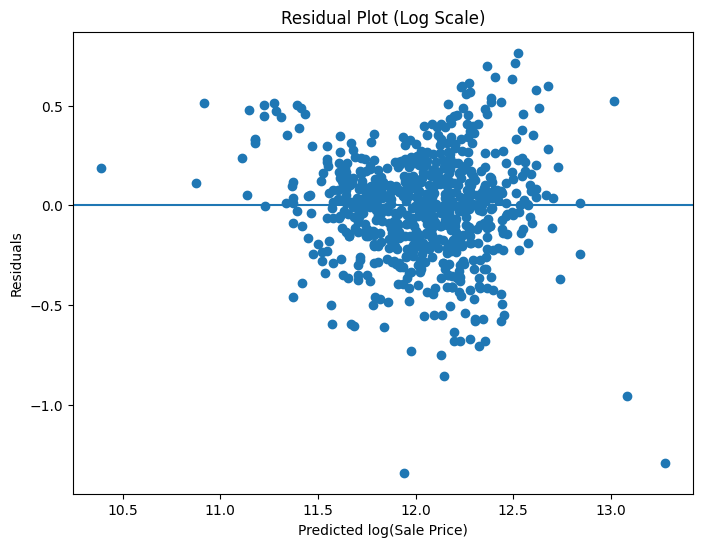

In [115]:
# Error plot to visualise the differences between the predicted and actual values in the test set.
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted log(Sale Price)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

In [121]:
# Print the coefficients
print("Intercept:", model.intercept_)
print("Coefficients:")
print("Living Area:", model.coef_[0])
print("Garage Area:", model.coef_[1])
print("R2 Score:", r2)
print("Median Price:", property_df['Sale_Price'].median())

Intercept: 5.56216606277004
Coefficients:
Living Area: 0.8308352142953023
Garage Area: 0.0739249302932676
R2 Score: 0.5772134013071122
Median Price: 160000.0


**Coefficients interpretation in the context of the prediction:**  
Living Area (B = 0.83)  
For a house priced at 160 000 (median), a 1% increase in living area increases the expected sale price by approximately 0.83% to 161 328.  
This confirms living space is the primary value driver.  
  
Garage Area (B = 0.074)  
A 1% increase in garage area increases sale price by approximately 0.07% to 160 118.4.  
Garage space adds value, but its effect is secondary.

**Conclusion**  
The data suggestes that functional space is more important than layout for most buyers they also value parking/storage and usable living area more than the layout of the structure. The log–log regression model explains approximately 57.7% of the variation in property sale prices, indicating moderate predictive performance. Residual analysis shows that the log transformation effectively stabilised variance and linearised the relationship between predictors and the target variable, with residuals randomly dispersed around zero. Living area emerged as the primary determinant of house prices, exhibiting a strong positive elasticity, while garage area contributed a smaller but statistically meaningful effect. Although the model performs well for average-priced properties, it shows reduced accuracy for high-value homes, suggesting that additional predictors such as location, quality, or age may further improve performance.